# Module 3.8 — Physics-Informed Neural Networks (PINNs)

**The newest approach — and the most misunderstood.**
PINNs are not replacing CFD. They are a complementary tool that excels where traditional CFD struggles: inverse problems, data assimilation, and parameter estimation. Knowing their strengths and fundamental limitations will save you from the hype and let you use them productively.

**The key idea:**
Instead of discretising the PDE on a mesh, represent the solution as a neural network $\hat{u}(x,t;\theta)$ and train it to satisfy the PDE residual + boundary/initial conditions simultaneously. Auto-differentiation gives exact derivatives of the network output — no grid, no stencil.

**Roadmap:**
1. The traditional CFD vs. PINN comparison — architecturally
2. The loss function — how the PDE becomes a training objective
3. Why auto-differentiation is the key enabler
4. Strengths and limitations — an honest assessment
5. Inverse problems — where PINNs genuinely outperform CFD
6. Implementation: PINN for 1D Burgers' equation concept
7. The frontier: neural operators (FNO, DeepONet)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 0. Primer — What *Is* a Neural Network? (Foundation for Everything Below)

**If you've never touched a neural network, start here — the rest of this notebook assumes this.**

### Physical analogy: curve fitting with a lot more knobs

You already know curve fitting: given scattered data points, you fit a line $y = mx + b$ by turning two knobs, $m$ and $b$, until the line matches the data as closely as possible.

A neural network is the **same idea, with thousands of knobs instead of two**, arranged so the resulting curve can bend into far more complex shapes than a straight line.

```
Curve fit:      y = m x + b                    (2 knobs: m, b)
Neural net:     u(x) = knob-tunable function    (thousands of knobs)
                 with enough knobs and the right shape,
                 it can approximate almost ANY continuous function
```

This is the **universal approximation** property — it's the entire reason neural networks are useful for representing a PDE solution $u(x,t)$ later in this notebook.

### The math: what the "knobs" actually do

A single hidden layer network looks like this:

$$\hat{u}(x;\theta) = W_2\,\sigma(W_1 x + b_1) + b_2$$

Reading it left to right:
- $W_1 x + b_1$ — a **linear transform** (just like $mx+b$), producing several intermediate values at once
- $\sigma(\cdot)$ — a **nonlinear "squashing" function** (commonly $\tanh$). This is what allows bending — stack enough of these and you get arbitrarily complex shapes. Without it, stacking linear transforms would just collapse back into one big linear transform (a straight line again).
- $W_2(\cdot) + b_2$ — combines the bent intermediate values into the final output

$\theta = \{W_1, b_1, W_2, b_2\}$ are **all the knobs** — the network's parameters.

### Training = turning the knobs by gradient descent

Just like curve fitting minimizes the distance between the line and the data points, network training minimizes a **loss function**:

$$\mathcal{L}(\theta) = \sum_i \left(\hat{u}(x_i;\theta) - u_i\right)^2$$

...where $(x_i, u_i)$ are labeled data points (if you have them — note that a PINN often won't).

Training nudges every knob a little in the direction that reduces the loss:

$$\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}(\theta) \qquad \text{(}\eta\text{ = learning rate)}$$

**Backpropagation** (a.k.a. reverse-mode automatic differentiation) is just an efficient algorithm for computing $\nabla_\theta \mathcal{L}$ — the "which direction do I turn each of these thousands of knobs" — via the chain rule applied mechanically through the network's computation graph.

**Why this matters for PINNs specifically:** the *same* chain-rule machinery that computes gradients with respect to the **weights** ($\partial \mathcal{L}/\partial W_1$, etc., for training) can just as easily compute gradients with respect to the **inputs** ($\partial \hat{u}/\partial x$, $\partial \hat{u}/\partial t$). That second use is exactly what a PINN needs to plug $\hat{u}$ into a PDE — covered in Section 3 below.

### Quick check
Before continuing: in the code cell below, you'll watch a tiny hand-built network learn to fit a curve using *nothing but numpy* — no autodiff library, gradients derived and coded by hand. Watch for: (1) the loss decreasing over iterations, (2) the fitted curve visually converging onto the target. This is the "turning knobs" process made concrete.

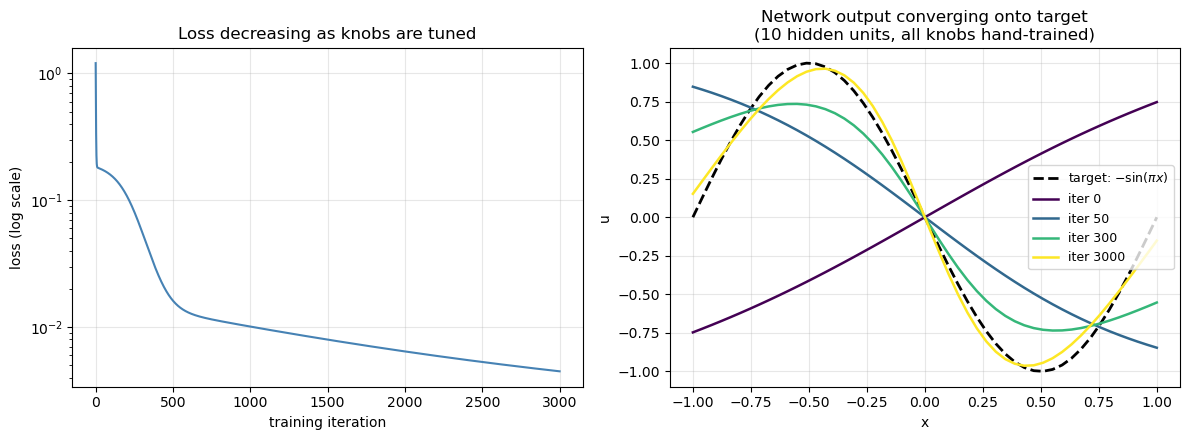

Final loss: 0.004480  (started at 1.206788)
Total knobs trained: 31


In [2]:
# ── A tiny neural network, trained by hand (no autodiff library) ──────────────
# Goal: fit u(x) = -sin(pi*x) on [-1,1] using a 1-hidden-layer network.
# Every gradient below is derived analytically and coded explicitly —
# this IS backpropagation, just written out instead of hidden inside a library.

np.random.seed(0)

# ── Target data (the "curve to fit") ──────────────────────────────────────────
x_data = np.linspace(-1, 1, 50).reshape(1, -1)      # shape (1, N)
u_data = -np.sin(np.pi * x_data)                     # shape (1, N)

# ── Network: x -> [linear -> tanh] -> [linear] -> u_hat ───────────────────────
H = 10  # hidden units ("knobs" scale with this)
W1 = np.random.randn(H, 1) * 0.5   # shape (H, 1)
b1 = np.zeros((H, 1))
W2 = np.random.randn(1, H) * 0.5   # shape (1, H)
b2 = np.zeros((1, 1))

def forward(x):
    z1 = W1 @ x + b1        # (H, N)
    a1 = np.tanh(z1)        # (H, N)  <- the nonlinear "bend"
    out = W2 @ a1 + b2      # (1, N)
    return out, a1

lr = 0.1
n_iters = 3000
losses = []
snapshots = {}  # capture the fitted curve at a few points in training

for it in range(n_iters + 1):
    out, a1 = forward(x_data)
    err = out - u_data                       # (1, N)
    loss = np.mean(err**2)
    losses.append(loss)

    if it in (0, 50, 300, 3000):
        snapshots[it] = out.copy()

    # ── Manual backpropagation (chain rule, by hand) ──────────────────────────
    N = x_data.shape[1]
    d_out = 2 * err / N                      # dL/d(out)
    dW2 = d_out @ a1.T                       # dL/dW2
    db2 = np.sum(d_out, axis=1, keepdims=True)
    d_a1 = W2.T @ d_out                      # dL/d(a1)
    d_z1 = d_a1 * (1 - a1**2)                # tanh'(z) = 1 - tanh(z)^2
    dW1 = d_z1 @ x_data.T                    # dL/dW1
    db1 = np.sum(d_z1, axis=1, keepdims=True)

    # ── Gradient descent: turn every knob a little ────────────────────────────
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

# ── Visualise: loss decreasing + fit converging onto the target ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogy(losses, color='steelblue')
axes[0].set_xlabel('training iteration'); axes[0].set_ylabel('loss (log scale)')
axes[0].set_title('Loss decreasing as knobs are tuned')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_data.flatten(), u_data.flatten(), 'k--', lw=2, label='target: $-\\sin(\\pi x)$')
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))
for c, (it, out) in zip(colors, snapshots.items()):
    axes[1].plot(x_data.flatten(), out.flatten(), color=c, lw=1.8, label=f'iter {it}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u')
axes[1].set_title(f'Network output converging onto target\n({H} hidden units, all knobs hand-trained)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final loss: {losses[-1]:.6f}  (started at {losses[0]:.6f})')
print(f'Total knobs trained: {W1.size + b1.size + W2.size + b2.size}')

## 1. Traditional CFD vs. PINNs — Two Philosophies

### Traditional CFD

```
PDE: ∂u/∂t + u∂u/∂x = ν∂²u/∂x²
     ↓ Discretise on mesh
     ↓ u[j, i, n] = array of numbers at grid points
     ↓ ∂u/∂x ≈ (u[j,i+1]-u[j,i-1])/(2Δx)  ← finite difference
     ↓ Build A*u = b  ← linear system
     ↓ Solve by direct/iterative method
     → discrete solution at grid points
```

### PINNs

```
PDE: ∂u/∂t + u∂u/∂x = ν∂²u/∂x²
     ↓ Represent solution as neural network
     ↓ û(x,t;θ) = network with parameters θ
     ↓ Compute ∂û/∂x, ∂²û/∂x², ∂û/∂t  ← auto-differentiation (exact!)
     ↓ PDE residual: R(x,t) = ∂û/∂t + û∂û/∂x - ν∂²û/∂x²
     ↓ Loss = ||R||² + ||BC||² + ||IC||² + ||data||²
     ↓ Minimise loss by gradient descent
     → continuous function û(x,t) that approximately solves PDE
```

## 2. The Loss Function — PDE as a Training Objective

$$\mathcal{L}(\theta) = \underbrace{\lambda_{\text{pde}} \sum_{i}|\mathcal{R}(x_i, t_i; \theta)|^2}_{\text{PDE residual at collocation points}} + \underbrace{\lambda_{\text{bc}} \sum_{j}|\hat{u} - u_{\text{bc}}|^2}_{\text{BC/IC conditions}} + \underbrace{\lambda_{\text{data}} \sum_{k}|\hat{u} - u_{\text{data}}|^2}_{\text{optional: measurement data}}$$

**Collocation points** are scattered randomly inside the domain — no mesh. After training, you can query $\hat{u}(x,t)$ at any point without rerunning the solver.

## 3. Auto-Differentiation — The Key Enabler

### Why this is different from finite differences

For a neural network $\hat{u}(x) = \sigma(W_2\sigma(W_1 x + b_1) + b_2)$, automatic differentiation applies the chain rule exactly through the computation graph:

$$\frac{\partial\hat{u}}{\partial x} = \text{exact algebraic derivative} \quad \text{(no truncation error!)}$$

Contrast with FD: $\partial u/\partial x \approx (u_{i+1}-u_{i-1})/(2\Delta x)$ has $O(\Delta x^2)$ error.

**This means:** the PDE residual $\mathcal{R}$ is computed exactly. The only approximation is in the network's ability to represent the solution (the functional approximation error).

## 4. Honest Strengths and Limitations

| Property | CFD (FVM/FDM) | PINN |
|----------|---------------|------|
| Forward problem speed | ✅ Fast (ms–min) | ❌ Slow (min–hours training) |
| Grid required? | ✅ Yes — mesh generation effort | ❌ No — scatter collocation points |
| Sharp gradients/shocks | ✅ Handled by TVD/Riemann | ❌ Difficult — spectral bias of networks |
| Inverse problems | ❌ Complex separate framework | ✅ Natural — add data loss term |
| Sparse data assimilation | ❌ Complex | ✅ Just add $||\hat{u}-u_{\text{meas}}||^2$ to loss |
| Error guarantees | ✅ Via mesh convergence study | ❌ None in general |
| Multi-query (same PDE, many params) | ❌ Re-solve each time | ⚠️ Re-train or use neural operators |
| Industry readiness | ✅ Mature, trusted | ⚠️ Research, limited validation |

### The spectral bias problem

Neural networks learn **low-frequency components first**. A PINN trained on a problem with sharp gradients (boundary layer, shock) will represent the smooth parts well but struggle to capture the sharp features — exactly where traditional CFD excels.

Mitigation strategies: Fourier feature embeddings, adaptive activation functions, domain decomposition. Still an active research area.

## 5. Inverse Problems — Where PINNs Shine

### The problem CFD cannot easily solve

You measure velocity at 50 points in an experimental flow. You want to recover: the pressure field (unmeasured), the viscosity (unknown), or the boundary conditions.

**Traditional CFD approach:** parametric study — try many values, compare with measurements. Computationally expensive.

**PINN approach:** add measurement data to the loss and let the network simultaneously satisfy the PDE and match the data. The unknown parameters become additional optimisation variables:

$$\theta^*, \nu^* = \arg\min_{\theta, \nu} \mathcal{L}_{\text{pde}}(\theta; \nu) + \mathcal{L}_{\text{data}}(\theta)$$

This is **one optimisation problem** — no iterative CFD solves, no parameter sweeps. Raissi et al. (2020) demonstrated viscosity identification from noisy velocity data, recovering the correct Re with ~1% error.

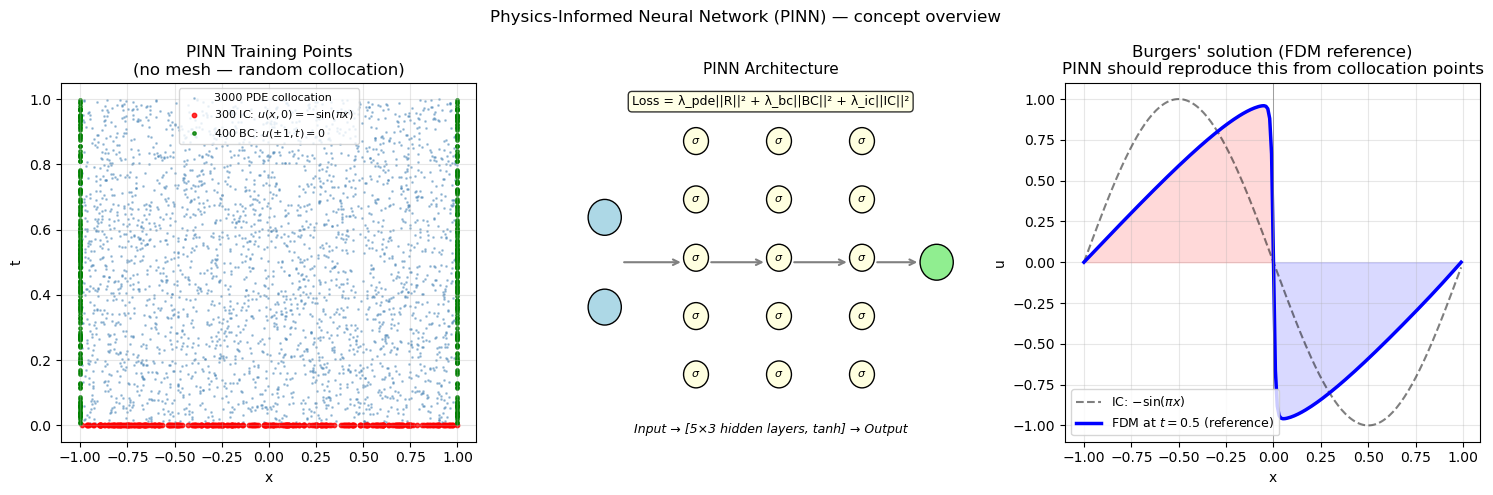

A trained PINN would give û(x,t) ≈ u_FDM(x,t) for any (x,t) in [-1,1]×[0,1].
No mesh required — but training takes ~1000× longer than solving with FDM.


In [3]:
# ── PINN concept: visualise the training setup ────────────────────────────────
# Show collocation points, the loss function components, and training intuition.
# Full PINN training requires PyTorch/JAX — this visualises the concept.

np.random.seed(42)

# ── Collocation point sampling for Burgers' equation on [-1,1]×[0,1] ─────────
n_pde  = 3000   # interior PDE collocation points
n_ic   = 300    # initial condition points (t=0)
n_bc   = 200    # boundary condition points (x=±1)

x_pde = np.random.uniform(-1, 1, n_pde)
t_pde = np.random.uniform( 0, 1, n_pde)
x_ic  = np.random.uniform(-1, 1, n_ic)
t_ic  = np.zeros(n_ic)
t_bc  = np.random.uniform( 0, 1, n_bc)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Left: collocation points ──────────────────────────────────────────────────
axes[0].scatter(x_pde, t_pde, s=1, c='steelblue', alpha=0.4, label=f'{n_pde} PDE collocation')
axes[0].scatter(x_ic, t_ic, s=10, c='red', alpha=0.8, label=f'{n_ic} IC: $u(x,0)=-\\sin(\\pi x)$')
axes[0].scatter([-1]*n_bc, t_bc, s=6, c='green', alpha=0.8, label=f'{2*n_bc} BC: $u(\\pm 1,t)=0$')
axes[0].scatter([ 1]*n_bc, t_bc, s=6, c='green', alpha=0.8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title('PINN Training Points\n(no mesh — random collocation)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-1.1, 1.1); axes[0].set_ylim(-0.05, 1.05)

# ── Middle: network architecture ──────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
ax.set_title('PINN Architecture', fontsize=11)

# Input
for k, label in enumerate(['x', 't']):
    y = 3 + k*2
    ax.add_patch(plt.Circle((1, y), 0.4, color='lightblue', ec='k', zorder=5))
    ax.text(1, y, label, ha='center', va='center', fontsize=12, fontweight='bold')

# Hidden layers
layer_x = [3.2, 5.2, 7.2]
for lx in layer_x:
    for ny in [1.5, 2.8, 4.1, 5.4, 6.7]:
        ax.add_patch(plt.Circle((lx, ny), 0.3, color='lightyellow', ec='k'))
        ax.text(lx, ny, '$\\sigma$', ha='center', va='center', fontsize=8)

# Output
ax.add_patch(plt.Circle((9, 4), 0.4, color='lightgreen', ec='k', zorder=5))
ax.text(9, 4, '$\\hat{u}$', ha='center', va='center', fontsize=12, fontweight='bold')

# Connections
for x1, x2 in [(1.4,2.9), (3.5,4.9), (5.5,6.9), (7.5,8.6)]:
    ax.annotate('', xy=(x2,4), xytext=(x1,4), arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.text(5, 0.2, 'Input → [5×3 hidden layers, tanh] → Output',
        ha='center', fontsize=9, style='italic')
ax.text(5, 7.5, 'Loss = λ_pde||R||² + λ_bc||BC||² + λ_ic||IC||²',
        ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Right: traditional CFD vs PINN solution ───────────────────────────────────
# Show the reference FDM solution of Burgers
N_ref = 200;  nu_ref = 0.01/np.pi
dx_ref = 2.0/N_ref;  x_ref = np.linspace(-1, 1, N_ref, endpoint=False)
u_ref = -np.sin(np.pi * x_ref)
dt_ref = 0.0005;  T_ref = 0.5
nt_ref = int(T_ref/dt_ref)
for _ in range(nt_ref):
    u_r = u_ref.copy()
    u_plus = np.roll(u_r, -1); u_minus = np.roll(u_r, 1)
    adv = np.where(u_r > 0, u_r*(u_r-u_minus)/dx_ref, u_r*(u_plus-u_r)/dx_ref)
    visc = nu_ref*(u_plus - 2*u_r + u_minus)/dx_ref**2
    u_ref = u_r - dt_ref*adv + dt_ref*visc
    u_ref[0] = u_ref[-1] = 0.0

axes[2].plot(x_ref, -np.sin(np.pi*x_ref), 'k--', lw=1.5, alpha=0.5, label='IC: $-\\sin(\\pi x)$')
axes[2].plot(x_ref, u_ref, 'b-', lw=2.5, label=f'FDM at $t={T_ref}$ (reference)')
axes[2].fill_between(x_ref, u_ref, 0, where=u_ref<0, alpha=0.15, color='blue')
axes[2].fill_between(x_ref, u_ref, 0, where=u_ref>0, alpha=0.15, color='red')
axes[2].set_xlabel('x'); axes[2].set_ylabel('u')
axes[2].set_title(f"Burgers' solution (FDM reference)\n"
                   'PINN should reproduce this from collocation points')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
axes[2].axvline(0, color='gray', lw=0.5)

plt.suptitle('Physics-Informed Neural Network (PINN) — concept overview', fontsize=12)
plt.tight_layout()
plt.show()

print('A trained PINN would give û(x,t) ≈ u_FDM(x,t) for any (x,t) in [-1,1]×[0,1].')
print('No mesh required — but training takes ~1000× longer than solving with FDM.')

## 6. The Frontier: Neural Operators

### The limitation of PINNs for parametric problems

A PINN trained on $\nu = 0.01$ must be **retrained** for $\nu = 0.1$. Each training run takes hours. For a design optimisation loop with 1000 evaluations at different parameters, PINNs are impractical.

### Neural operators: learn the solution map

Instead of learning $\hat{u}(x,t)$ for one set of parameters, learn the **operator** that maps parameters or input fields to solution fields:

$$\mathcal{G}: a(x) \to u(x) \quad \text{(e.g., boundary condition → velocity field)}$$

**Fourier Neural Operator (FNO, Li et al. 2020):** operates in Fourier space — efficiently learns the global correlations in a PDE solution. Trained on a family of solutions, predicts new solutions in milliseconds.

**DeepONet (Lu et al. 2021):** uses two sub-networks — a branch net (encodes the input function) and a trunk net (evaluates at query points).

**Current status (2025):** FNO/DeepONet are being actively integrated into industrial CFD pipelines for:
- Aerodynamic shape optimisation (replace CFD inner loop)
- Real-time flow prediction for digital twins
- Turbulence closure modelling (data-driven $\nu_t$)

## Summary

| Aspect | Key point |
|--------|-----------|
| Core idea | Neural network satisfies PDE as soft constraint in loss function |
| Derivatives | Auto-differentiation — exact, no truncation error |
| Key strength | Inverse problems, data assimilation, mesh-free |
| Key weakness | Slow training, spectral bias (poor near shocks), no error guarantees |
| Appropriate use | Inverse problems, parameter identification, multi-physics coupling |
| Not appropriate | Fast forward solves, high-Re turbulence, shock-dominated flows |
| Future direction | Neural operators (FNO, DeepONet) for parametric problems |

**Bottom line:** PINNs are a valuable addition to the computational engineer's toolkit — not a replacement for CFD, but a complementary approach for problems that are awkward with traditional methods.

---
**End of Module 3.** You have now covered: turbulence (RANS, models, law of the wall), mesh generation, higher-order schemes (TVD), multigrid, unsteady flows, compressible flow, and PINNs.

**Next:** Module 4 — Projects: applying everything to complete engineering problems.